# Task 2: Migration Pattern Analysis with Data Integration

*Assignment submitted by: Shreya Volety*

### **Step 1: Cleaning filenames**


The data provided for analysis is structured, but I rename files to include only statecodes. Ideally the function should create a folder for each year-2-year migration and resave files in that structure, but for the purposes of this exercise, I don't include a more detail data ingestion pipeline.

<span style="color: red;"><b>GenAI use in this step: Minimal</b></span>

I have not used Generative AI for any code in this step of the process.

In [6]:
import pandas as pd
import numpy as np
import pathlib
import os
from pathlib import Path
import matplotlib.pyplot as plt
!pip install xlrd
!pip install us
import us

In [8]:
base = Path.cwd()
migration_dir = str(base) + '/raw_data/migration/'
clean_dir = str(base)+'/clean_data/'

In [261]:
for i in os.listdir(migration_dir):
    print(i)
    old_path = os.path.join(migration_dir, i)
    name, ext = os.path.splitext(i)
    new_name = name[-3:-1] + ext
    new_path = os.path.join(migration_dir, new_name)
    print(new_name)
    os.rename(old_path,new_path) #renaming filenames to be statecodes
    

co0304DEi.xls
DE.xls
co0304VTi.xls
VT.xls
co0304MTi.xls
MT.xls
co0304TXi.xls
TX.xls
co0304VAi.xls
VA.xls
co0304MAi.xls
MA.xls
co0304KYi.xls
KY.xls
co0304ILi.xls
IL.xls
co0304AZi.xls
AZ.xls
.DS_Store
or
co0304IAi.xls
IA.xls
co0304COi.xls
CO.xls
co0304NJi.xls
NJ.xls
co0304ORi.xls
OR.xls
co0304UTi.xls
UT.xls
co0304KSi.xls
KS.xls
co0304NMi.xls
NM.xls
co0304DCi.xls
DC.xls
co0304OKi.xls
OK.xls
co0304LAi.xls
LA.xls
Co0304WAi.xls
WA.xls
co0304NYi.xls
NY.xls
co0304MSi.xls
MS.xls
co0304WYi.xls
WY.xls
co0304NVi.xls
NV.xls
co0304MIi.xls
MI.xls
co0304NCi.xls
NC.xls
co0304IDi.xls
ID.xls
co0304MEi.xls
ME.xls
co0304WVi.xls
WV.xls
co0304OHi.xls
OH.xls
co0304FLi.xls
FL.xls
co0304MDi.xls
MD.xls
co0304ARi.xls
AR.xls
co0304SCi.xls
SC.xls
co0304AKi.xls
AK.xls
co0304RIi.xls
RI.xls
co0304SDi.xls
SD.xls
co0304INi.xls
IN.xls
co0304GAi.xls
GA.xls
co0304WIi.xls
WI.xls
co0304MOi.xls
MO.xls
co0304ALi.xls
AL.xls
co0304NEi.xls
NE.xls
CO0304NDi.xls
ND.xls
co0304CTi.xls
CT.xls
co0304HIi.xls
HI.xls
co0304MNi.xls
MN.xls


### **Step 2: Cleaning data and saving cleaned data**

I run one loop to accomplish the following steps in cleaning the data:
    
a. While reading files, I skip the first 4 rows with file metadata, and set the first 4 rows as header - this file format is true for all the excel files. Ideally, this file reading can be made more robust using openpyxl and dynamic file cleaning.

b. I then check for consistency in number of columns after collapsing the four header column names into 1. Ideally we should have 9 columns of data. I rename the columns to be standard and usable.

c. Following this, I'm ensuring that the way the FIPS code are being read and formatted is accurate. This is more of a data cleaning check that anything else.

d. I construct a directional key - in 2 columns (for ex: Migration from A to B) and a sorted pair key (A<->B , where migration from A to B and B to A is considered equivalent)

e. We know that for the 50 states in the US - FIPS codes range from 01 to 56. In the files, any code that is greater than 56 is attached to a summary column - either a state total or a county total or miscellaneous rows of information. For county-level analysis this information should be filtered out and stored separately. Most analysis is done on FIPS codes and I did not want these summary rows to throw the analysis in incorrect directions.

f. I filter out the summary rows, the rows that note non-migrants in the data and store each of these pieces separately, along with raw data. These are stored as multi-sheet excels

<span style="color: red;"><b>GenAI use in this step: Minimal</b></span>

The approach of cleaning/resaving is largely mine without an GenAI interference. I have only used it to add the validation checks, but not to clean up any further data ingestion processes.

In [328]:
def clean_part(x):
    x = str(x).strip()
    if x.startswith("Unnamed"):
        return np.nan
    return x

for i in os.listdir(migration_dir):
    if i.endswith('.xls'):
        statecode = i[:2]
        file_path = os.path.join(migration_dir, i)
        sample = pd.read_excel(file_path, skiprows=4, header=[0,1,2,3], dtype='str') #ideally, this information should not be hardcode
        # and there should be a JSON file that store information on file-structures of the IRS data changing, or there can be a dynamic way
        # to handle this - for this exercise I do not implement such a system, but noting that data ingestion should be less fragile.

        sample.columns = [
            " | ".join([clean_part(x) for x in col if pd.notna(clean_part(x))])
            for col in sample.columns
        ]

        if len(sample.columns) != 9: #parameters such as this maybe stored in JSON metadata files to prevent hardcoding.
            print(f"Unexpected columns in {i}")
            continue

        sample.columns = ['To_State_FIPS','To_County_FIPS','From_State_FIPS','From_County_FIPS',
                        'From_State_Code','Description','Returns','Exemptions','Agg_Adj_gross_income'] 
        #parameters such as this maybe stored in JSON metadata files to prevent hardcoding.

        for c in ['To_State_FIPS','To_County_FIPS','From_State_FIPS','From_County_FIPS']:
            sample[c] = sample[c].astype(str).str.strip()

        sample['To_State_FIPS'] = sample['To_State_FIPS'].str.zfill(2)
        sample['To_County_FIPS'] = sample['To_County_FIPS'].str.zfill(3)
        sample['From_State_FIPS'] = sample['From_State_FIPS'].str.zfill(2)
        sample['From_County_FIPS'] = sample['From_County_FIPS'].str.zfill(3)

        sample['from_FIPS'] = sample['From_State_FIPS'] + sample['From_County_FIPS']
        sample['to_FIPS'] = sample['To_State_FIPS'] + sample['To_County_FIPS']
        sample['pair_key'] = sample.apply(
                            lambda r: "-".join(sorted([r['from_FIPS'], r['to_FIPS']])),
                            axis=1
                            )
        sample['to_State'] = statecode

        from_state_num = pd.to_numeric(sample['From_State_FIPS'], errors='coerce')

        summary_df = sample[from_state_num > 56]
        non_migrants_df = sample[sample['from_FIPS'] == sample['to_FIPS']]
        summary_removed_df = sample[~((from_state_num > 56) | (sample['from_FIPS'] == sample['to_FIPS']))]

        output_path = str(base)+'/clean_data/'+statecode+'_clean.xlsx'

        with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
            print(f'''Cleaning and resaving file of state: {statecode}''')
            sample.to_excel(writer,sheet_name='Clean_primary',index=False)
            summary_df.to_excel(writer,sheet_name='County_State_summary',index=False)
            non_migrants_df.to_excel(writer,sheet_name='Non Migrant Counts',index=False)
            summary_removed_df.to_excel(writer,sheet_name='Non summ cols only',index=False)

    

Cleaning and resaving file of state: SD
Cleaning and resaving file of state: GA


Exception ignored in: <function ZipFile.__del__ at 0x105e4e5c0>
Traceback (most recent call last):
  File "/Users/svolety/miniconda3/envs/fe-course/lib/python3.11/zipfile.py", line 1895, in __del__
    self.close()
  File "/Users/svolety/miniconda3/envs/fe-course/lib/python3.11/zipfile.py", line 1912, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Cleaning and resaving file of state: HI
Cleaning and resaving file of state: SC
Cleaning and resaving file of state: KS
Cleaning and resaving file of state: IL
Cleaning and resaving file of state: IN
Cleaning and resaving file of state: OH
Cleaning and resaving file of state: WY
Cleaning and resaving file of state: NM
Cleaning and resaving file of state: MA
Cleaning and resaving file of state: OK
Cleaning and resaving file of state: MT
Cleaning and resaving file of state: NY
Cleaning and resaving file of state: NJ
Cleaning and resaving file of state: AR
Cleaning and resaving file of state: WI
Cleaning and resaving file of state: ME
Cleaning and resaving file of state: LA
Cleaning and resaving file of state: UT
Cleaning and resaving file of state: CO
Cleaning and resaving file of state: MD
Cleaning and resaving file of state: NH
Cleaning and resaving file of state: MS
Cleaning and resaving file of state: NE
Cleaning and resaving file of state: MI
Cleaning and resaving file of state: VT


### **Step 3: Completing first 3 parts of the tasks - county-pair analysis, county-total analysis and NYMA analysis**

I want to construct one larger dataframe with all county-level data and I run a loop to concat all 50 dataframes read from state files and convert numeric data cols to the appropriate data type.

In [9]:
sample = pd.read_excel(clean_dir+'ME'+'_clean.xlsx',sheet_name='Non summ cols only')

In [16]:
total_df = pd.DataFrame(columns=sample.columns)

for i in os.listdir(clean_dir):
    if i.endswith('.xlsx'):
        print(f'''Reading: {i}''')
        temp = pd.read_excel(clean_dir+i,sheet_name='Non summ cols only',dtype='str')
        total_df = pd.concat([total_df,temp],axis=0)

Reading: WI_clean.xlsx
Reading: AZ_clean.xlsx
Reading: TN_clean.xlsx
Reading: CO_clean.xlsx
Reading: HI_clean.xlsx
Reading: MA_clean.xlsx
Reading: AR_clean.xlsx
Reading: WA_clean.xlsx
Reading: UT_clean.xlsx
Reading: MD_clean.xlsx
Reading: NC_clean.xlsx
Reading: TX_clean.xlsx
Reading: AL_clean.xlsx
Reading: RI_clean.xlsx
Reading: CT_clean.xlsx
Reading: MI_clean.xlsx
Reading: MN_clean.xlsx
Reading: DC_clean.xlsx
Reading: AK_clean.xlsx
Reading: ND_clean.xlsx
Reading: VT_clean.xlsx
Reading: OH_clean.xlsx
Reading: GA_clean.xlsx
Reading: KY_clean.xlsx
Reading: IL_clean.xlsx
Reading: ME_clean.xlsx
Reading: IA_clean.xlsx
Reading: VA_clean.xlsx
Reading: SD_clean.xlsx
Reading: DE_clean.xlsx
Reading: MS_clean.xlsx
Reading: ID_clean.xlsx
Reading: LA_clean.xlsx
Reading: WV_clean.xlsx
Reading: NJ_clean.xlsx
Reading: OK_clean.xlsx
Reading: NY_clean.xlsx
Reading: OR_clean.xlsx
Reading: IN_clean.xlsx
Reading: NM_clean.xlsx
Reading: FL_clean.xlsx
Reading: MT_clean.xlsx
Reading: MO_clean.xlsx
Reading: NH

In [17]:
cols = ['Returns','Agg_Adj_gross_income','Exemptions']
total_df= total_df[total_df["Returns"].str.replace(",", "").str.match(r"^\d+$", na=False)] 
total_df[cols] = total_df[cols].astype(int)
total_df = total_df.sort_values(by='Exemptions',ascending=False)

I use the file downloaded from here to work with FIPS codes and county names. The API call is limited to 1000 rows only, and I need data more expansive than that.

In [18]:
metadata = pd.read_csv(str(base)+'/State,_County_and_City_FIPS_Reference_Table_20260323.csv',dtype='str')
metadata = metadata.drop_duplicates(['StCnty FIPS Code']) #also contains city codes so there are multiple entries for each county which need to be dropped
metadata

,State Name,County Name,City Name,State Code,State FIPS Code,County Code,StCnty FIPS Code,City Code,StCntyCity FIPS Code
0,ALABAMA,AUTAUGA,AUTAUGAVILLE,AL,01,C001,01001,0220,010010220
6,ALABAMA,BALDWIN,BAY MINETTE,AL,01,C003,01003,0240,010030240
30,ALABAMA,BARBOUR,BAKER HILL,AL,01,C005,01005,0227,010050227
38,ALABAMA,BIBB,BRENT,AL,01,C007,01007,0460,010070460
47,ALABAMA,BLOUNT,ALLGOOD,AL,01,C009,01009,0074,010090074
...,...,...,...,...,...,...,...,...,...
40370,WYOMING,SWEETWATER,BAIROIL,WY,56,C037,56037,0033,560370033
40388,WYOMING,TETON,ALTA,WY,56,C039,56039,0028,560390028
40396,WYOMING,UINTA,CARTER,WY,56,C041,56041,0085,560410085
40403,WYOMING,WASHAKIE,TEN SLEEP,WY,56,C043,56043,0810,560430810


I map FIPS codes to county names using metadata from above.

In [19]:
total_df = total_df.merge(metadata[['County Name','StCnty FIPS Code']],how='left',left_on='from_FIPS',right_on='StCnty FIPS Code')
total_df = total_df.drop(columns=['StCnty FIPS Code'])
total_df = total_df.rename(columns={'County Name':'from_County'})
total_df = total_df.merge(metadata[['County Name','StCnty FIPS Code']],how='left',left_on='to_FIPS',right_on='StCnty FIPS Code')
total_df = total_df.drop(columns=['StCnty FIPS Code'])
total_df = total_df.rename(columns={'County Name':'to_County'})

Grouping columns by the pair-keys and sorting exemptions from highest to lowest.

In [20]:
pair_interactions = (
    total_df.groupby('pair_key')['Exemptions']
    .sum()
    .sort_values(ascending=False)
)

pair_interactions_df = pd.DataFrame()
pair_interactions_df['pair-key'] = pair_interactions.index.astype('str')
pair_interactions_df['Total migration flow'] = pair_interactions.values
pair_interactions_df[['county1','county2']] = pair_interactions_df['pair-key'].str.split('-', expand=True)

pair_interactions_df = pair_interactions_df.merge(metadata[['County Name','StCnty FIPS Code']],how='left',left_on='county1',right_on='StCnty FIPS Code')
pair_interactions_df = pair_interactions_df.drop(columns=['StCnty FIPS Code'])
pair_interactions_df = pair_interactions_df.rename(columns={'County Name':'County1 name'})

pair_interactions_df = pair_interactions_df.merge(metadata[['County Name','StCnty FIPS Code']],how='left',left_on='county2',right_on='StCnty FIPS Code')
pair_interactions_df = pair_interactions_df.drop(columns=['StCnty FIPS Code'])
pair_interactions_df = pair_interactions_df.rename(columns={'County Name':'County2 name'})

pair_interactions_df['state1'] = pair_interactions_df['county1'].str[:2]
pair_interactions_df['state2'] = pair_interactions_df['county2'].str[:2]

metadata_state = metadata.drop_duplicates(['State FIPS Code'])

pair_interactions_df = pair_interactions_df.merge(metadata_state[['State Name','State FIPS Code']],how='left',left_on='state1',right_on='State FIPS Code')
pair_interactions_df = pair_interactions_df.drop(columns=['State FIPS Code'])
pair_interactions_df = pair_interactions_df.rename(columns={'State Name':'State1 name'})

pair_interactions_df = pair_interactions_df.merge(metadata_state[['State Name','State FIPS Code']],how='left',left_on='state2',right_on='State FIPS Code')
pair_interactions_df = pair_interactions_df.drop(columns=['State FIPS Code'])
pair_interactions_df = pair_interactions_df.rename(columns={'State Name':'State2 name'})

pair_interactions_df['County pairs'] = pair_interactions_df['County1 name']+'-'+pair_interactions_df['County2 name']

#### **Identifying top 20 county pairs for migration flows**

In [21]:
pair_interactions_df.head(20)

,pair-key,Total migration flow,county1,county2,County1 name,County2 name,state1,state2,State1 name,State2 name,County pairs
0,06037-06071,67982,06037,06071,LOS ANGELES,SAN BERNARDINO,06,06,CALIFORNIA,CALIFORNIA,LOS ANGELES-SAN BERNARDINO
1,06037-06059,63896,06037,06059,LOS ANGELES,ORANGE,06,06,CALIFORNIA,CALIFORNIA,LOS ANGELES-ORANGE
2,12011-12086,43204,12011,12086,BROWARD,MIAMI-DADE,12,12,FLORIDA,FLORIDA,BROWARD-MIAMI-DADE
3,17031-17043,42666,17031,17043,COOK,DU PAGE,17,17,ILLINOIS,ILLINOIS,COOK-DU PAGE
4,48157-48201,39315,48157,48201,FORT BEND,HARRIS,48,48,TEXAS,TEXAS,FORT BEND-HARRIS
5,06059-06065,36482,06059,06065,ORANGE,RIVERSIDE,06,06,CALIFORNIA,CALIFORNIA,ORANGE-RIVERSIDE
6,06065-06071,35926,06065,06071,RIVERSIDE,SAN BERNARDINO,06,06,CALIFORNIA,CALIFORNIA,RIVERSIDE-SAN BERNARDINO
7,36047-36081,35733,36047,36081,KINGS,QUEENS,36,36,NEW YORK,NEW YORK,KINGS-QUEENS
8,48085-48113,33783,48085,48113,COLLIN,DALLAS,48,48,TEXAS,TEXAS,COLLIN-DALLAS
9,48113-48439,32092,48113,48439,DALLAS,TARRANT,48,48,TEXAS,TEXAS,DALLAS-TARRANT


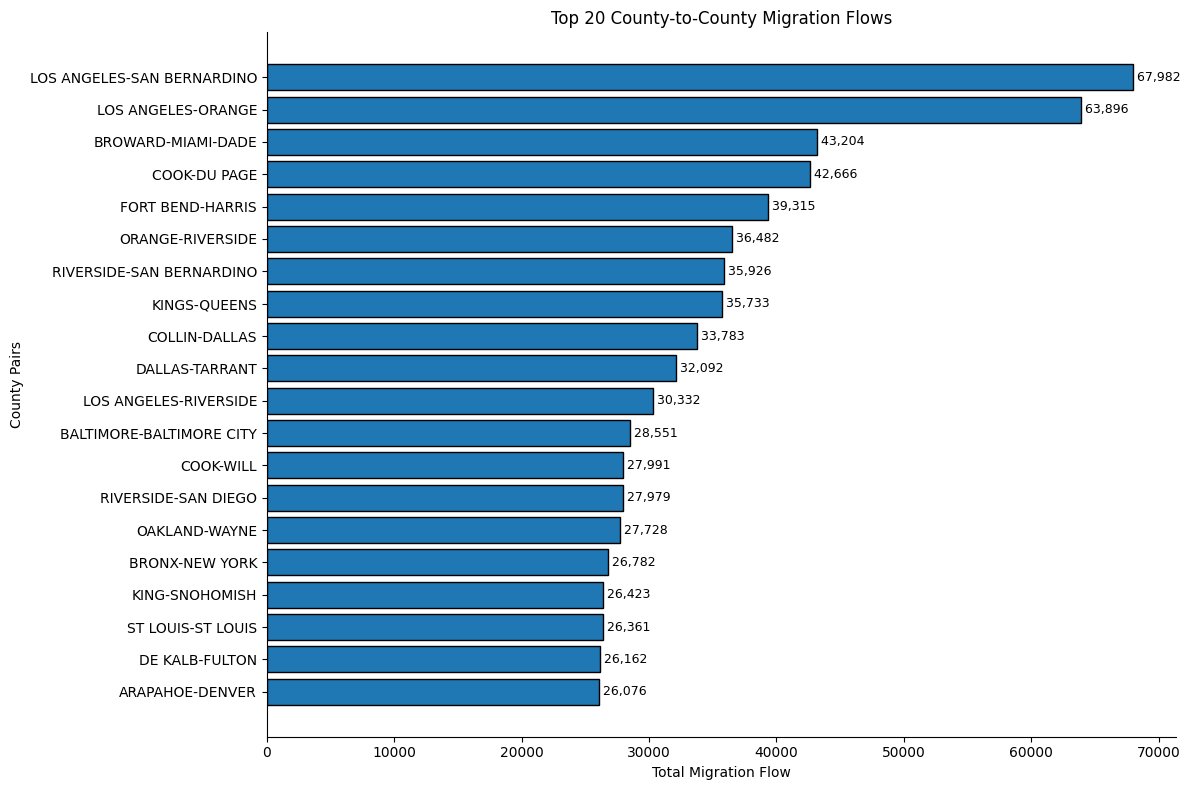

In [22]:
top_df = pair_interactions_df.sort_values(
    by='Total migration flow', ascending=False
).head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_df['County pairs'],
    top_df['Total migration flow'],
    edgecolor='black'
)

plt.gca().invert_yaxis()

plt.xlabel('Total Migration Flow')
plt.ylabel('County Pairs')
plt.title('Top 20 County-to-County Migration Flows')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

for i, v in enumerate(top_df['Total migration flow']):
    plt.text(v, i, f' {v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Quick Note: Most interactions are inter-state

In [23]:
inflow = total_df.groupby("to_FIPS")["Exemptions"].sum().sort_values(ascending=False)
inflow_df = pd.DataFrame()
inflow_df['FIPS'] = inflow.index
inflow_df['Inflows']= inflow.values
inflow_df = inflow_df.merge(metadata[['County Name','State FIPS Code', 'State Name', 'StCnty FIPS Code']],how='left',left_on='FIPS',right_on='StCnty FIPS Code')
inflow_df = inflow_df.drop(columns=['StCnty FIPS Code'])

outflow = total_df.groupby("from_FIPS")["Exemptions"].sum().sort_values(ascending=False)
outflow_df = pd.DataFrame()
outflow_df['FIPS'] = outflow.index
outflow_df['Outflows']= outflow.values
outflow_df = outflow_df.merge(metadata[['County Name','State FIPS Code', 'State Name', 'StCnty FIPS Code']],how='left',left_on='FIPS',right_on='StCnty FIPS Code')
outflow_df = outflow_df.drop(columns=['StCnty FIPS Code'])

#### **Identifying top 20 counties based on level of in-migration flows**

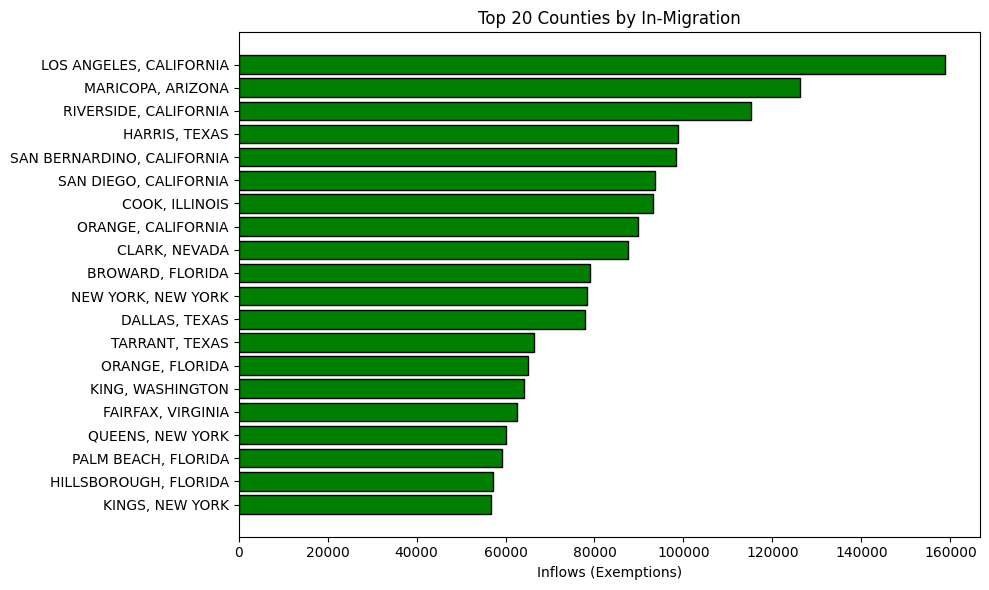

In [24]:
top_n = 20
plot_df = inflow_df.head(top_n).copy()
plot_df['label'] = plot_df['County Name'] + ', ' + plot_df['State Name']

plt.figure(figsize=(10, 6))
plt.barh(plot_df['label'][::-1], plot_df['Inflows'][::-1],edgecolor='black',color='green')
plt.title(f'Top {top_n} Counties by In-Migration')
plt.xlabel('Inflows (Exemptions)')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### **Identifying top 20 counties based on level of out-migration flows**

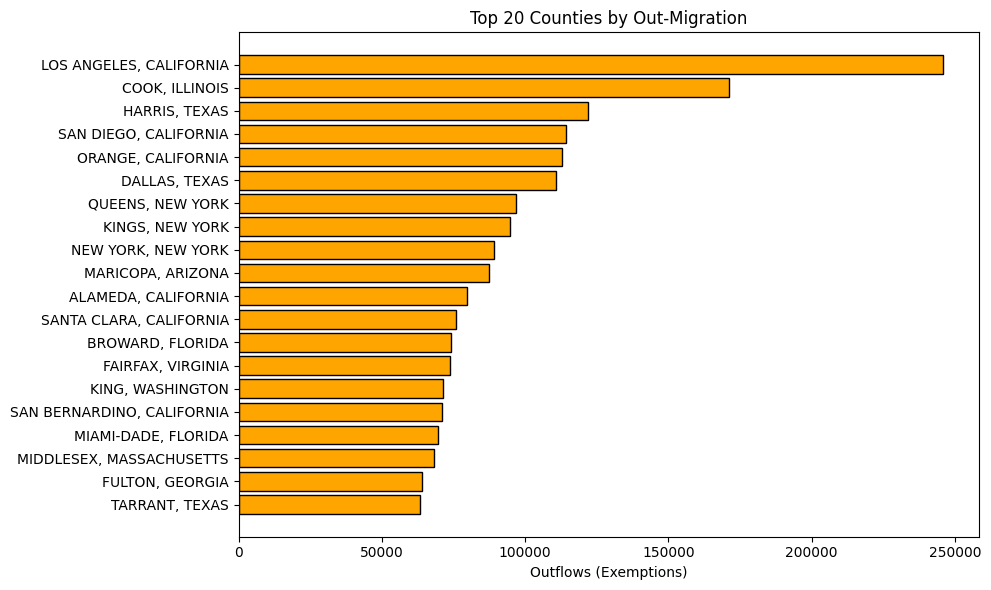

In [25]:
top_n = 20
plot_df = outflow_df.head(top_n).copy()
plot_df['label'] = plot_df['County Name'] + ', ' + plot_df['State Name']

plt.figure(figsize=(10, 6))
plt.barh(plot_df['label'][::-1], plot_df['Outflows'][::-1],edgecolor='black',color='orange')
plt.title(f'Top {top_n} Counties by Out-Migration')
plt.xlabel('Outflows (Exemptions)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Note**

1. Just noting a few observations here, from the 3 charts above. LA has the maximum number of inflows/outflows and we've seen from the pair-interactions plots above that most of this is inter-state. This is interesting to note.
2. There is a sharp drop-off from the county with most inflows to the one with the second-most - the distribution of inflows/outflows should reflect that there is high skewness - some counties get a lot of migration based on urbanity/location/income/density.

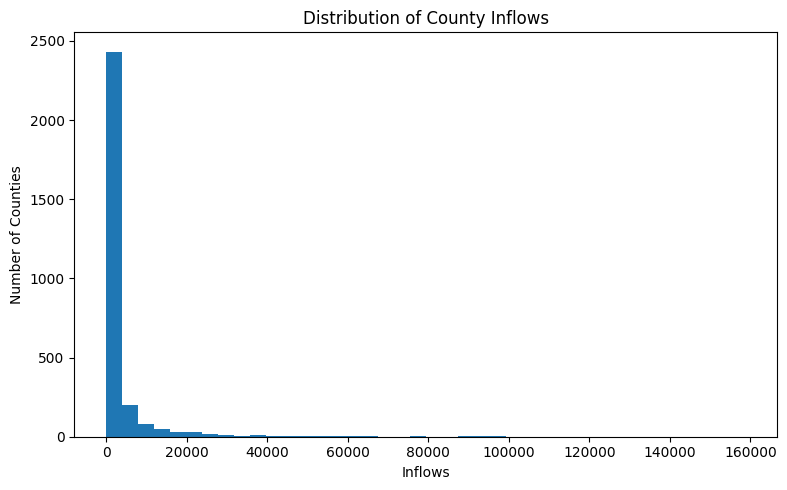

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(inflow_df['Inflows'], bins=40)
plt.title('Distribution of County Inflows')
plt.xlabel('Inflows')
plt.ylabel('Number of Counties')
plt.tight_layout()
plt.show()

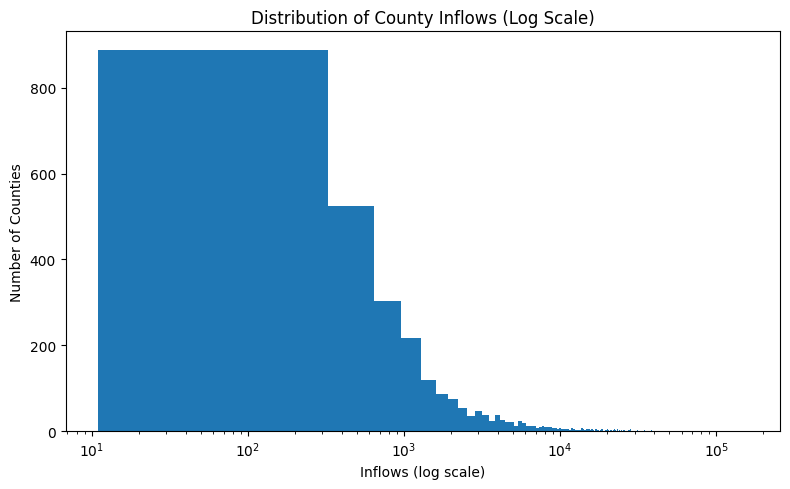

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(inflow_df['Inflows'] + 1, bins=500)
plt.xscale('log')
plt.title('Distribution of County Inflows (Log Scale)')
plt.xlabel('Inflows (log scale)')
plt.ylabel('Number of Counties')
plt.tight_layout()
plt.show()

This is exactly what we expect to observe, and given high skewnes the log scale reveals more structure to the data. Many counties get tens/hundreds of immigrants, but very few receive a very high volume. 

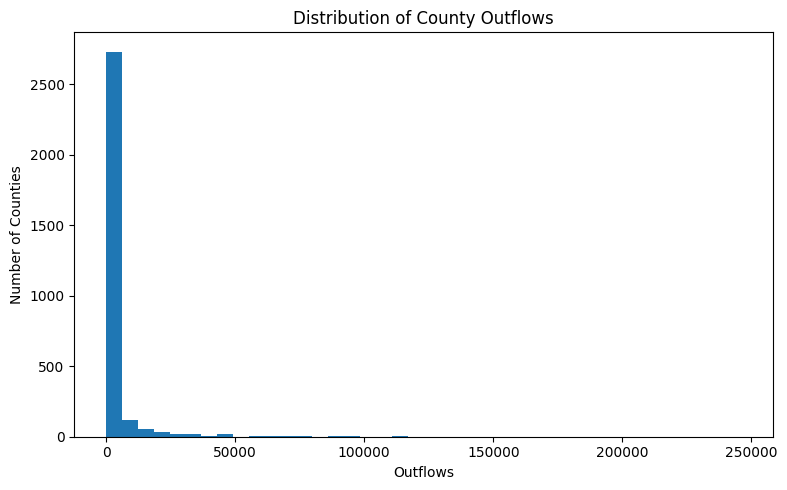

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(outflow_df['Outflows'], bins=40)
plt.title('Distribution of County Outflows')
plt.xlabel('Outflows')
plt.ylabel('Number of Counties')
plt.tight_layout()
plt.show()

**Note**

Similar structure for outflows. Also good to note that these flows are not normalized to population yet i.e. densely populated counties will naturally have more outflows than others. Further, there is a lot of inter-state migration in metropolitan areas which contributes to county-level outflows. 


In [29]:
meta_cols = ["County Name", "State FIPS Code", "State Name", "StCnty FIPS Code"]

flow_df = inflow_df.merge(
    outflow_df[["FIPS", "Outflows"]],
    on="FIPS",
    how="outer"
).fillna({"Inflows": 0, "Outflows": 0})

flow_df["Net Flow"] = flow_df["Inflows"] - flow_df["Outflows"]

ny_metro_fips = {
    # NYC boroughs
    "36005", "36047", "36061", "36081", "36085",
    # NY suburbs
    "36059", "36103", "36119", "36087", "36079",
    # NJ
    "34003", "34017", "34031", "34013", "34039",
    "34027", "34035", "34023", "34025", "34029",
    # CT
    "09001"
}

print(f'''Net flow (Inflow-Outflow) from New York Metropolitan area: {flow_df[flow_df['FIPS'].isin(ny_metro_fips)]['Net Flow'].sum()}''')


Net flow (Inflow-Outflow) from New York Metropolitan area: -146379.0


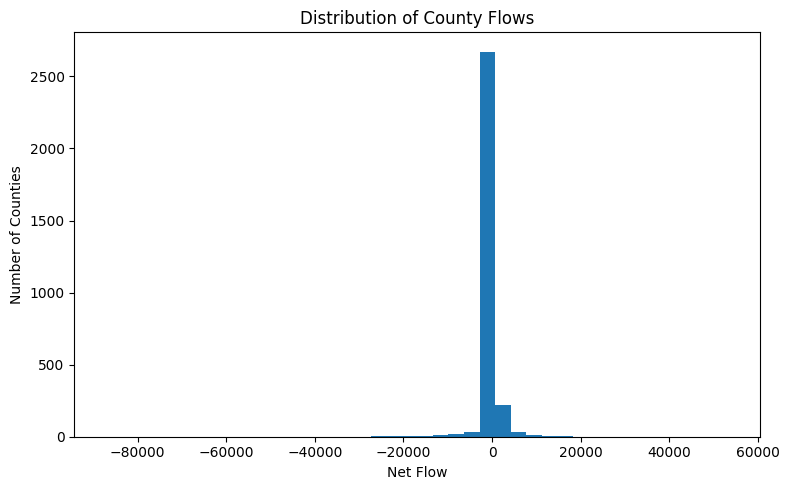

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(flow_df['Net Flow'], bins=40)
plt.title('Distribution of County Flows')
plt.xlabel('Net Flow')
plt.ylabel('Number of Counties')
plt.tight_layout()
plt.show()

**Note** - just visualizing something that is fairly intuitive from previous plots - most counties experience net flows that are 0, and very few will take in large number of migrants or lose large number of residents.

In [31]:
network_df = total_df[
    (
        total_df["from_FIPS"].isin(ny_metro_fips) & ~total_df["to_FIPS"].isin(ny_metro_fips)
    ) |
    (
        ~total_df["from_FIPS"].isin(ny_metro_fips) & total_df["to_FIPS"].isin(ny_metro_fips)
    )
].copy()

network_df = network_df.sort_values("Exemptions", ascending=False).head(top_n)

county_lookup = (
    metadata
    .set_index("StCnty FIPS Code")[["County Name", "State Name"]]
)

def make_label(fips):
    try:
        row = county_lookup.loc[fips]
        return f"{row['County Name']}, {row['State Name']}"
    except:
        return str(fips)


top_into_metro = (
    network_df[network_df["to_FIPS"].isin(ny_metro_fips)]
    .groupby("from_FIPS")["Exemptions"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .rename("Flow Into Metro")
)

top_out_of_metro = (
    network_df[network_df["from_FIPS"].isin(ny_metro_fips)]
    .groupby("to_FIPS")["Exemptions"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .rename("Flow Out of Metro")
)

print("\nTop counties sending migrants INTO NYC metro:")
display(top_into_metro.rename_axis("FIPS").reset_index().assign(County=lambda x: x["FIPS"].map(make_label)))

print("\nTop counties receiving migrants FROM NYC metro:")
display(top_out_of_metro.rename_axis("FIPS").reset_index().assign(County=lambda x: x["FIPS"].map(make_label)))


Top counties sending migrants INTO NYC metro:


,FIPS,Flow Into Metro,County
0,09009,3663,"NEW HAVEN, CONNECTICUT"
1,06037,1750,"LOS ANGELES, CALIFORNIA"
2,34021,1420,"MERCER, NEW JERSEY"
3,34037,1329,"SUSSEX, NEW JERSEY"



Top counties receiving migrants FROM NYC metro:


,FIPS,Flow Out of Metro,County
0,09009,6751,"NEW HAVEN, CONNECTICUT"
1,12011,3862,"BROWARD, FLORIDA"
2,36071,3622,"ORANGE, NEW YORK"
3,34021,3496,"MERCER, NEW JERSEY"
4,12099,3095,"PALM BEACH, FLORIDA"
5,12086,2530,"MIAMI-DADE, FLORIDA"
6,36027,2396,"DUTCHESS, NEW YORK"
7,06037,2204,"LOS ANGELES, CALIFORNIA"
8,34037,1966,"SUSSEX, NEW JERSEY"
9,12095,1757,"ORANGE, FLORIDA"


**Note** : Strong out-migration to Florida (knowing that outflows were net positive from the area in this time period.) Noting here to see if NLP analysis will reveal something in the future.


### **Step 4: Using GenAI tools to augment migration data with other data points**

<span style="color: red;"><b>GenAI use in this step: Extensive</b></span>

The following is the prompt/series of prompts with Claude. I provided claude with context on migration data and the assignment step 4 prompt. Initially I failed to clarify the time period of relevance. Therefore a few of the options could not be used - the ACS dataset for example was not available at the time of 03-04.

The 3 sources that Claude proposed were:

Income data: Census Bureau — Census 2000 or Small Area Income & Poverty Estimates (SAIPE) 2003/2004 - for median Household income at the county-level.

Median Home value: Freddie Mac / FHFA House Price Index has county-level data going back to the early 2000s

Population: Census Bureau Population Estimates, Vintage 2004

This data seemed fairly intuitive to me to use, the hypotheses we could test with these are:

1. Do people move to counties with higher-income?
2. Do people move to counties with cheaper homes?
3. Does density in counties contribute to trends in migration?

The code in the cell below is produced by Claude to pull data from mutliple APIs and join the data points on county FIPS codes and the data was saved down. File is included in the zip file provided.

In [32]:

import requests
import time
import sys

BASE = "https://api.census.gov/data"
OUTPUT_FILE = "county_enrichment_2003_2004.csv"

def fetch(url, params=None, label=""):
    print(f"  Fetching {label}...")
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    print(f"  ✓ {len(df):,} rows")
    return df

def fips(state_col, county_col, df):
    return df[state_col].str.zfill(2) + df[county_col].str.zfill(3)

# ── 1. SAIPE — Median Household Income & Poverty ─────────────────────────────
print("\n[1/3] Median Household Income + Poverty (Census SAIPE)")
saipe_cols = "NAME,SAEMHI_PT,SAEPOVALL_PT,SAEPOVRTALL_PT"

df_inc03 = fetch(
    f"{BASE}/timeseries/poverty/saipe",
    {"get": saipe_cols, "for": "county:*", "YEAR": "2003"},
    "SAIPE 2003"
)
time.sleep(0.5)

df_inc04 = fetch(
    f"{BASE}/timeseries/poverty/saipe",
    {"get": saipe_cols, "for": "county:*", "YEAR": "2004"},
    "SAIPE 2004"
)

df_inc03["fips"] = fips("state", "county", df_inc03)
df_inc04["fips"] = fips("state", "county", df_inc04)

df_inc03 = df_inc03.rename(columns={
    "NAME":           "county_name",
    "SAEMHI_PT":      "median_hh_income_2003",
    "SAEPOVALL_PT":   "poverty_count_2003",
    "SAEPOVRTALL_PT": "poverty_rate_pct_2003"
})[["fips","county_name","median_hh_income_2003","poverty_count_2003","poverty_rate_pct_2003"]]

df_inc04 = df_inc04.rename(columns={
    "SAEMHI_PT":      "median_hh_income_2004",
    "SAEPOVALL_PT":   "poverty_count_2004",
    "SAEPOVRTALL_PT": "poverty_rate_pct_2004"
})[["fips","median_hh_income_2004","poverty_count_2004","poverty_rate_pct_2004"]]

df_income = df_inc03.merge(df_inc04, on="fips", how="outer")

# ── 2. Census 2000 SF3 — Median Home Value ────────────────────────────────────

print("\n[2/3] Median Home Value (Census 2000 dec/sf3 — H076001)")
time.sleep(0.5)

home_var = None
for var in ["H076001", "H085001", "HCT051001"]:
    try:
        df_home = fetch(
            f"{BASE}/2000/dec/sf3",
            {"get": f"NAME,{var}", "for": "county:*"},
            f"Census 2000 SF3 home values (var={var})"
        )
        home_var = var
        break
    except Exception as e:
        print(f"  Variable {var} failed: {e}, trying next…")

if home_var is None:
    raise RuntimeError("Could not fetch home value from Census 2000 dec/sf3 — all variable codes failed.")

df_home["fips"] = fips("state", "county", df_home)
df_home = df_home.rename(columns={home_var: "median_home_value_2000"}) \
                 [["fips","median_home_value_2000"]]

# ── 3. Intercensal Population Estimates 2003 & 2004 ──────────────────────────
print("\n[3/3] Population Estimates (Census Intercensal 2000-2010)")

time.sleep(0.5)

df_pop03 = fetch(
    f"{BASE}/2000/pep/int_population",
    {"get": "GEONAME,POP,DATE_", "for": "county:*", "DATE_": "5"},
    "Population 2003 (DATE_=5)"
)
time.sleep(0.5)

df_pop04 = fetch(
    f"{BASE}/2000/pep/int_population",
    {"get": "GEONAME,POP,DATE_", "for": "county:*", "DATE_": "6"},
    "Population 2004 (DATE_=6)"
)

df_pop03["fips"] = fips("state", "county", df_pop03)
df_pop04["fips"] = fips("state", "county", df_pop04)
df_pop03 = df_pop03.rename(columns={"POP": "population_2003"})[["fips","population_2003"]]
df_pop04 = df_pop04.rename(columns={"POP": "population_2004"})[["fips","population_2004"]]
df_pop = df_pop03.merge(df_pop04, on="fips", how="outer")

# ── Merge all three ───────────────────────────────────────────────────────────
print("\n[Merging] Joining all datasets on FIPS code...")
df = df_income \
    .merge(df_home, on="fips", how="left") \
    .merge(df_pop,  on="fips", how="left") \
    .sort_values("fips") \
    .reset_index(drop=True)

# Clean up numeric columns
numeric_cols = [
    "median_hh_income_2003","median_hh_income_2004",
    "poverty_count_2003","poverty_count_2004",
    "poverty_rate_pct_2003","poverty_rate_pct_2004",
    "median_home_value_2000",
    "population_2003","population_2004"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ Done! Saved → {OUTPUT_FILE}")
print(f"   Rows    : {len(df):,} counties")
print(f"   Columns : {list(df.columns)}")
print(f"\nPreview (first 5 rows):")
print(df.head().to_string(index=False))



[1/3] Median Household Income + Poverty (Census SAIPE)
  Fetching SAIPE 2003...
  ✓ 3,141 rows
  Fetching SAIPE 2004...
  ✓ 3,141 rows

[2/3] Median Home Value (Census 2000 dec/sf3 — H076001)
  Fetching Census 2000 SF3 home values (var=H076001)...
  ✓ 3,219 rows

[3/3] Population Estimates (Census Intercensal 2000-2010)
  Fetching Population 2003 (DATE_=5)...
  ✓ 3,221 rows
  Fetching Population 2004 (DATE_=6)...
  ✓ 3,221 rows

[Merging] Joining all datasets on FIPS code...

✅ Done! Saved → county_enrichment_2003_2004.csv
   Rows    : 3,141 counties
   Columns : ['fips', 'county_name', 'median_hh_income_2003', 'poverty_count_2003', 'poverty_rate_pct_2003', 'median_hh_income_2004', 'poverty_count_2004', 'poverty_rate_pct_2004', 'median_home_value_2000', 'population_2003', 'population_2004']

Preview (first 5 rows):
 fips    county_name  median_hh_income_2003  poverty_count_2003  poverty_rate_pct_2003  median_hh_income_2004  poverty_count_2004  poverty_rate_pct_2004  median_home_value_

In [33]:
county_enrichment = pd.read_csv('county_enrichment_2003_2004.csv',dtype={"fips": str})
flow_df = flow_df.merge(county_enrichment,left_on='FIPS',right_on='fips')

In [34]:
county_enrichment

,fips,county_name,median_hh_income_2003,poverty_count_2003,poverty_rate_pct_2003,median_hh_income_2004,poverty_count_2004,poverty_rate_pct_2004,median_home_value_2000,population_2003,population_2004
0,01001,Autauga County,44241.0,4926,10.4,45379.0,5627.0,11.6,94800.0,46800.0,48366.0
1,01003,Baldwin County,41961.0,15753,10.1,42227.0,16089.0,10.0,122500.0,151509.0,156266.0
2,01005,Barbour County,26062.0,5717,22.2,26495.0,6109.0,23.9,68600.0,28594.0,28287.0
3,01007,Bibb County,32924.0,3383,16.8,34055.0,3476.0,17.1,74600.0,21399.0,21721.0
4,01009,Blount County,37758.0,6503,11.9,38643.0,6844.0,12.4,86800.0,53457.0,54124.0
...,...,...,...,...,...,...,...,...,...,...,...
3136,56037,Sweetwater County,52541.0,3192,8.6,54700.0,3028.0,8.1,104200.0,37450.0,38026.0
3137,56039,Teton County,57485.0,1067,5.6,59568.0,928.0,4.9,365400.0,19066.0,19467.0
3138,56041,Uinta County,48658.0,2063,10.6,50184.0,1922.0,9.8,89400.0,19480.0,19470.0
3139,56043,Washakie County,40357.0,860,11.0,41900.0,837.0,10.8,83600.0,7976.0,7960.0


In [35]:
flow_df['log_income_2004'] = np.log(flow_df['median_hh_income_2004'])
flow_df['log_home_value_2000'] = np.log(flow_df['median_home_value_2000'])
flow_df['net_flow_per_capita_2004'] = flow_df['Net Flow'] / flow_df['population_2004']
flow_df['flow_ratio'] = flow_df['Inflows'] / (flow_df['Outflows'] + 1)
flow_df['poverty_rate_2004'] = flow_df['poverty_rate_pct_2004']
flow_df['log_population_2004'] = np.log(flow_df['population_2004'])

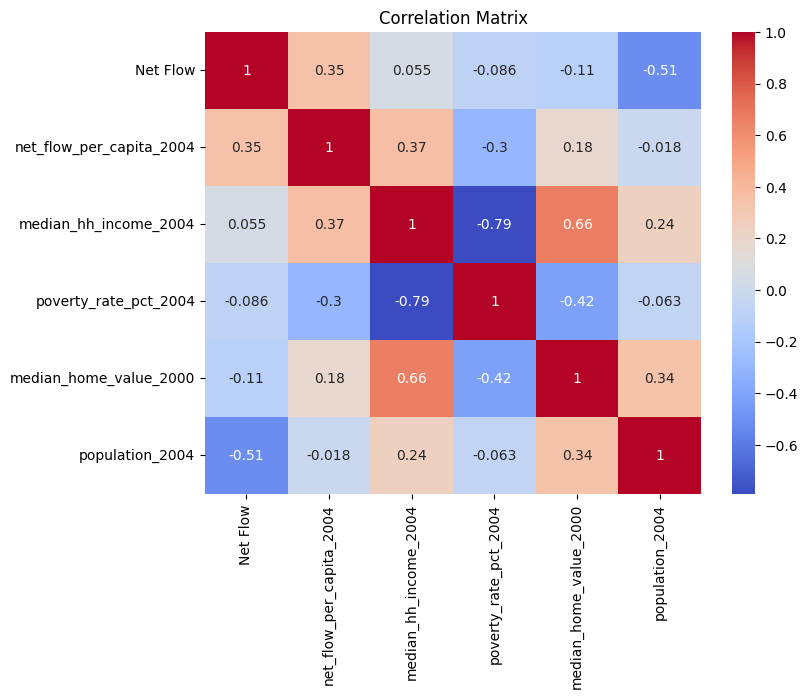

In [38]:
cols = [
    'Net Flow',
    'net_flow_per_capita_2004',
    'median_hh_income_2004',
    'poverty_rate_pct_2004',
    'median_home_value_2000',
    'population_2004'
]

corr = flow_df[cols].corr()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

We observe weak relationships with the indicators included - at broad level there is not much information revealed from addition of this data

Initially, I plot basic relationships of the target variable i.e. our normalized migration (per capita) versus log income, home value and population - we know these datatsets are typically skewed so we take log transforms to reveal more structure.

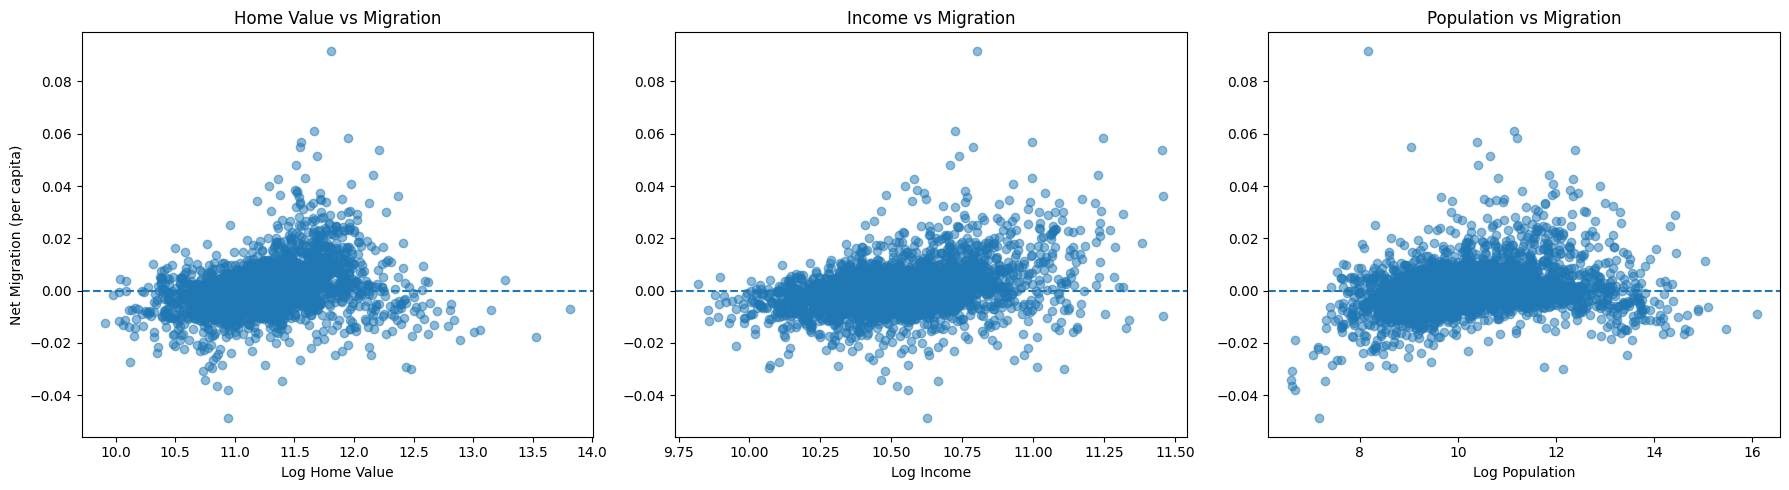

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

features = [
    ('log_home_value_2000', 'Home Value'),
    ('log_income_2004', 'Income'),
    ('log_population_2004', 'Population')
]

for i, (col, label) in enumerate(features):
    axs[i].scatter(flow_df[col], flow_df['net_flow_per_capita_2004'], alpha=0.5)
    axs[i].set_xlabel(f'Log {label}')
    axs[i].set_title(f'{label} vs Migration')
    axs[i].axhline(0, linestyle='--')

axs[0].set_ylabel('Net Migration (per capita)')

plt.tight_layout()
plt.show()

<span style="color: red;"><b>GenAI use in this step: Continued and Extensive</b></span>

Given that there is still a fair amount of "clustering" in these scatter plots and the relationships are not completely clear cut, it's important to see if there's some segmentation that can reveal further relationships. This is the next prompt to claude, to conceptualize a segmentation that might reveal any relationships that are more significant than what we see in the heatmap above. The segmentation and visualization is done on population - to see if urban/suburban/rural areas demonstrate different relationships.

Here, we do observe more significant relationship of the variables in the suburban areas - all 3 variables seem to affect people in suburban areas more than in urban/rural areas. The relationships here are meaningfully strong - it is not unfair to conclude that people want to migrate from lower income counties to suburban neighborhoods (that might typically be more affluent, more space etc.,). People do leave counties with poverty rates and are attracted to move to suburbs with more spacious higher "quality" homes.

Ultimately the suburbs are gaining migrants.


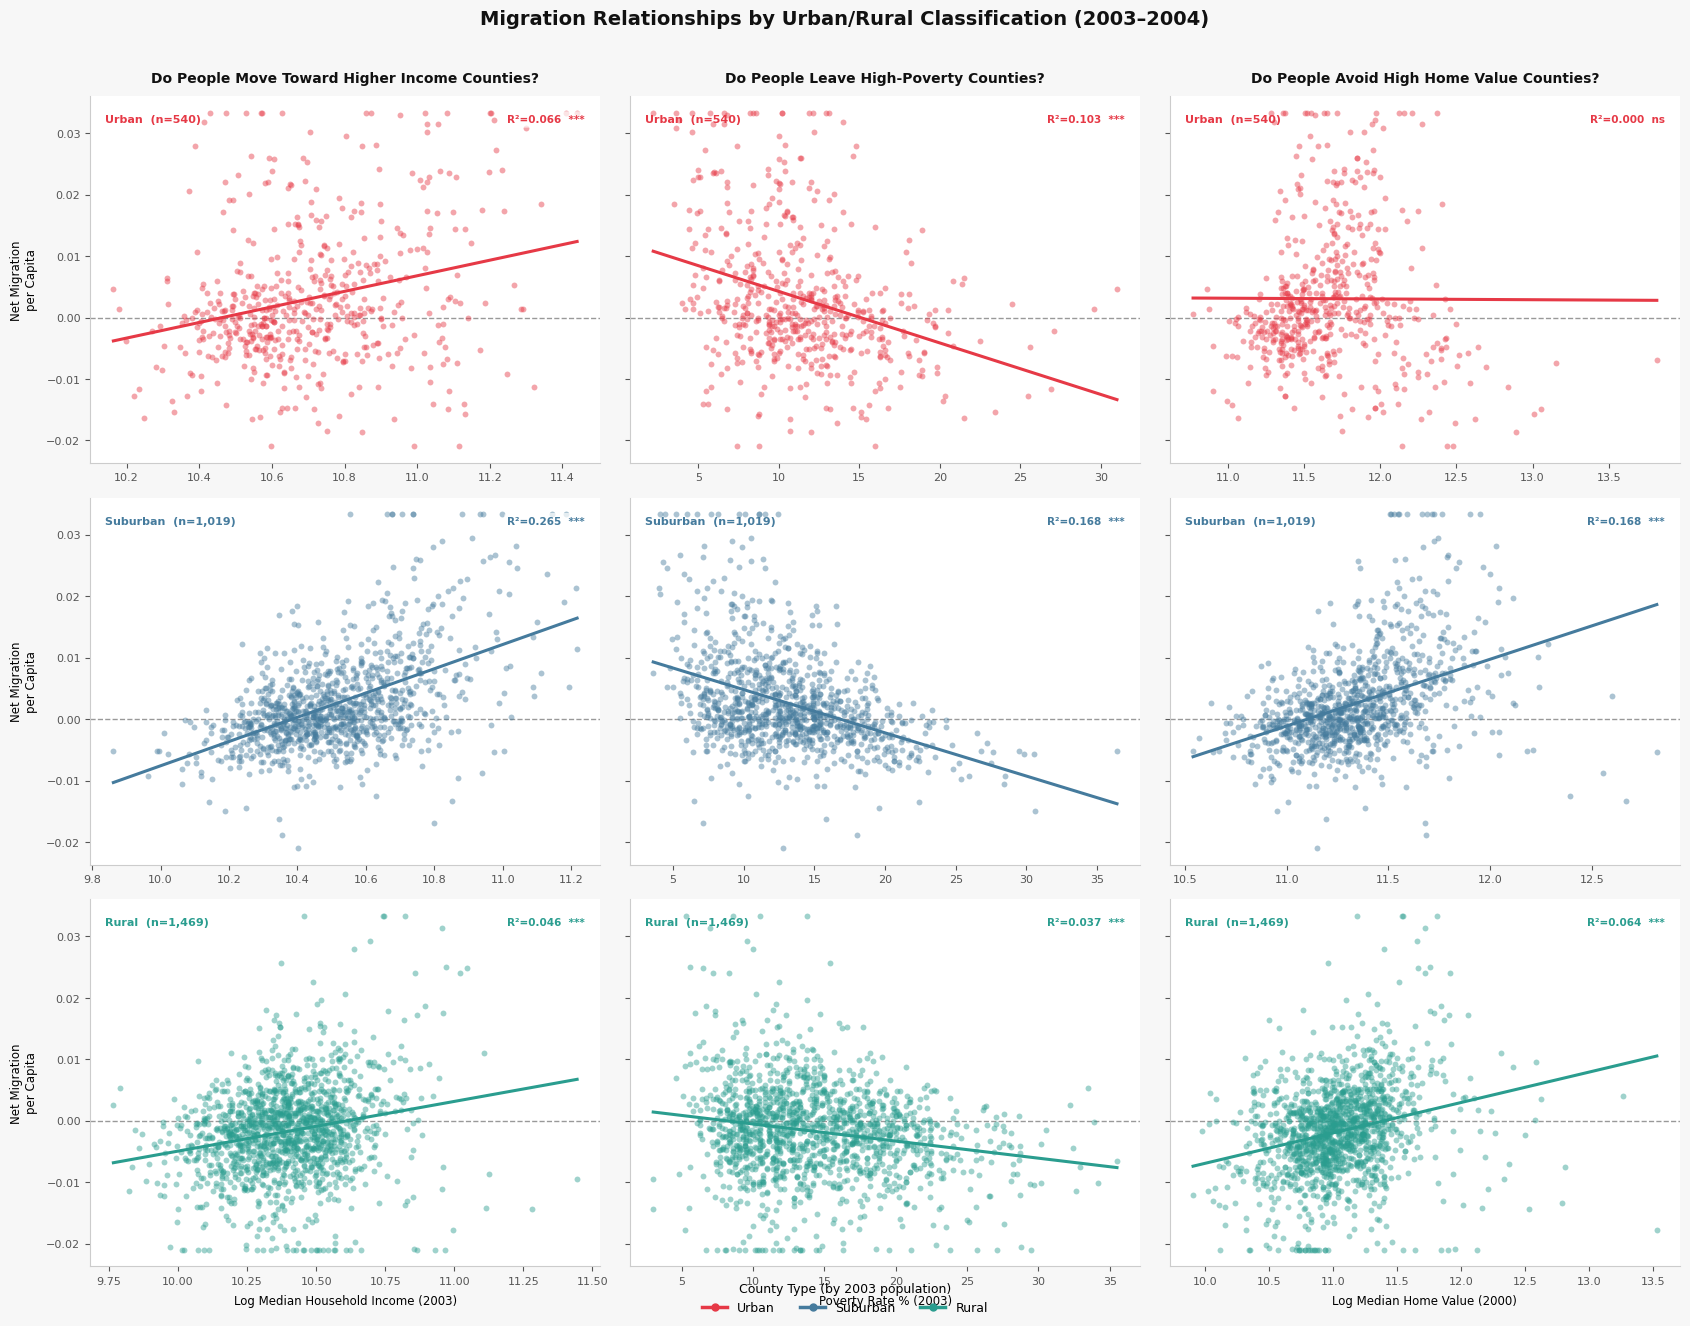

In [42]:

import matplotlib.lines as mlines
from scipy import stats

def classify(pop):
    if pop >= 100_000:
        return "Urban"
    elif pop >= 25_000:
        return "Suburban"
    else:
        return "Rural"

flow_df["urban_rural"] = flow_df["population_2003"].apply(classify)

# ── Derived variables ─────────────────────────────────────────────────────────
flow_df["net_migration_per_capita_2003"] = flow_df["Net Flow"] / flow_df["population_2003"]
flow_df["log_median_income_2003"]        = np.log(flow_df["median_hh_income_2003"])
flow_df["log_home_value_2000"]           = np.log(flow_df["median_home_value_2000"])

df = flow_df.copy()
# Drop rows with nulls in key columns
plot_df = df.dropna(subset=[
    "net_migration_per_capita_2003", "log_median_income_2003",
    "poverty_rate_pct_2003", "log_home_value_2000", "population_2003"
]).copy()

# Winsorise net migration per capita at 1st/99th percentile to remove outliers
lo, hi = plot_df["net_migration_per_capita_2003"].quantile([0.01, 0.99])
plot_df["net_migration_per_capita_2003"] = plot_df["net_migration_per_capita_2003"].clip(lo, hi)


TIERS        = ["Urban", "Suburban", "Rural"]
COLORS       = {"Urban": "#E63946", "Suburban": "#457B9D", "Rural": "#2A9D8F"}
ALPHA        = 0.45
DOT_SIZE     = 18
TREND_WIDTH  = 2.2

X_VARS = [
    ("log_median_income_2003",    "Log Median Household Income (2003)",  "Do People Move Toward Higher Income Counties?"),
    ("poverty_rate_pct_2003","Poverty Rate % (2003)",               "Do People Leave High-Poverty Counties?"),
    ("log_home_value_2000",       "Log Median Home Value (2000)",        "Do People Avoid High Home Value Counties?"),
]

fig, axes = plt.subplots(3, 3, figsize=(17, 13), sharey="row")
fig.patch.set_facecolor("#f7f7f7")

for col_idx, (xvar, xlabel, row_title) in enumerate(X_VARS):
    for row_idx, tier in enumerate(TIERS):
        ax  = axes[row_idx][col_idx]
        sub = plot_df[plot_df["urban_rural"] == tier]
        ax.set_facecolor("#ffffff")

        # Scatter
        ax.scatter(
            sub[xvar], sub["net_migration_per_capita_2003"],
            color=COLORS[tier], alpha=ALPHA, s=DOT_SIZE,
            linewidths=0, zorder=2
        )

        # Zero reference line
        ax.axhline(0, color="#999999", linewidth=1, linestyle="--", zorder=1)

        # OLS trend line
        x_clean = sub[xvar].replace([np.inf, -np.inf], np.nan).dropna()
        y_clean = sub.loc[x_clean.index, "net_migration_per_capita_2003"]
        if len(x_clean) > 10:
            slope, intercept, r, p, _ = stats.linregress(x_clean, y_clean)
            x_line = np.linspace(x_clean.min(), x_clean.max(), 200)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=COLORS[tier],
                    linewidth=TREND_WIDTH, zorder=3)
            # R² and p-value annotation
            sig   = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
            ax.text(0.97, 0.95, f"R²={r**2:.3f}  {sig}",
                    transform=ax.transAxes, fontsize=7.5,
                    ha="right", va="top", color=COLORS[tier],
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none"))

        # Subplot formatting
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#cccccc")
        ax.tick_params(labelsize=8, colors="#555555")
        ax.set_xlabel(xlabel if row_idx == 2 else "", fontsize=8.5, labelpad=6)
        ax.set_ylabel("Net Migration per Capita" if col_idx == 0 else "",
                      fontsize=8.5, labelpad=6)

        # Tier label on left column
        if col_idx == 0:
            ax.set_ylabel(f"Net Migration\nper Capita", fontsize=8.5)

        # Column title on top row
        if row_idx == 0:
            ax.set_title(row_title, fontsize=10, fontweight="bold",
                         color="#111111", pad=10)

        # Tier badge top-left
        ax.text(0.03, 0.95, f"{tier}  (n={len(sub):,})",
                transform=ax.transAxes, fontsize=8, fontweight="bold",
                va="top", color=COLORS[tier])


handles = [mlines.Line2D([], [], color=COLORS[t], linewidth=2.5,
                          marker="o", markersize=5, label=t) for t in TIERS]
fig.legend(handles=handles, loc="lower center", ncol=3,
           fontsize=9, frameon=False,
           title="County Type (by 2003 population)",
           title_fontsize=9)

fig.suptitle(
    "Migration Relationships by Urban/Rural Classification (2003–2004)",
    fontsize=14, fontweight="bold", y=1.01, color="#111111"
)

plt.tight_layout()
plt.show()

We can potentially confirm our earlier conclusion by observing which counties have had the net MOST migration per capita, and as we see the top results are primarily the suburbs based on our classification. This further builds the idea of migration towards the suburbs.

In [43]:
flow_df.sort_values(by=('net_migration_per_capita_2003'),ascending=False)['urban_rural'].head(20)

1704       Rural
328     Suburban
630     Suburban
2312    Suburban
1847       Rural
2763       Urban
1700    Suburban
2359    Suburban
2000       Urban
802     Suburban
367        Urban
366        Urban
362        Urban
360        Urban
485     Suburban
453        Urban
345        Urban
337        Urban
258        Urban
492        Rural
Name: urban_rural, dtype: object


── Belt Summary ──────────────────────────────────────────────
           Counties  Avg_Net_Flow  Total_Net_Flow  Pct_Positive  Avg_Per_Capita  Avg_Inflow  Avg_Outflow
belt                                                                                                    
Other           825        -92.71        -76489.0         36.73            -0.0     1211.32      1304.03
Rust Belt       822       -279.89       -230069.0         56.69             0.0     3867.55      4147.44
Sun Belt       1385        221.34        306558.0         48.88             0.0     4041.69      3820.34


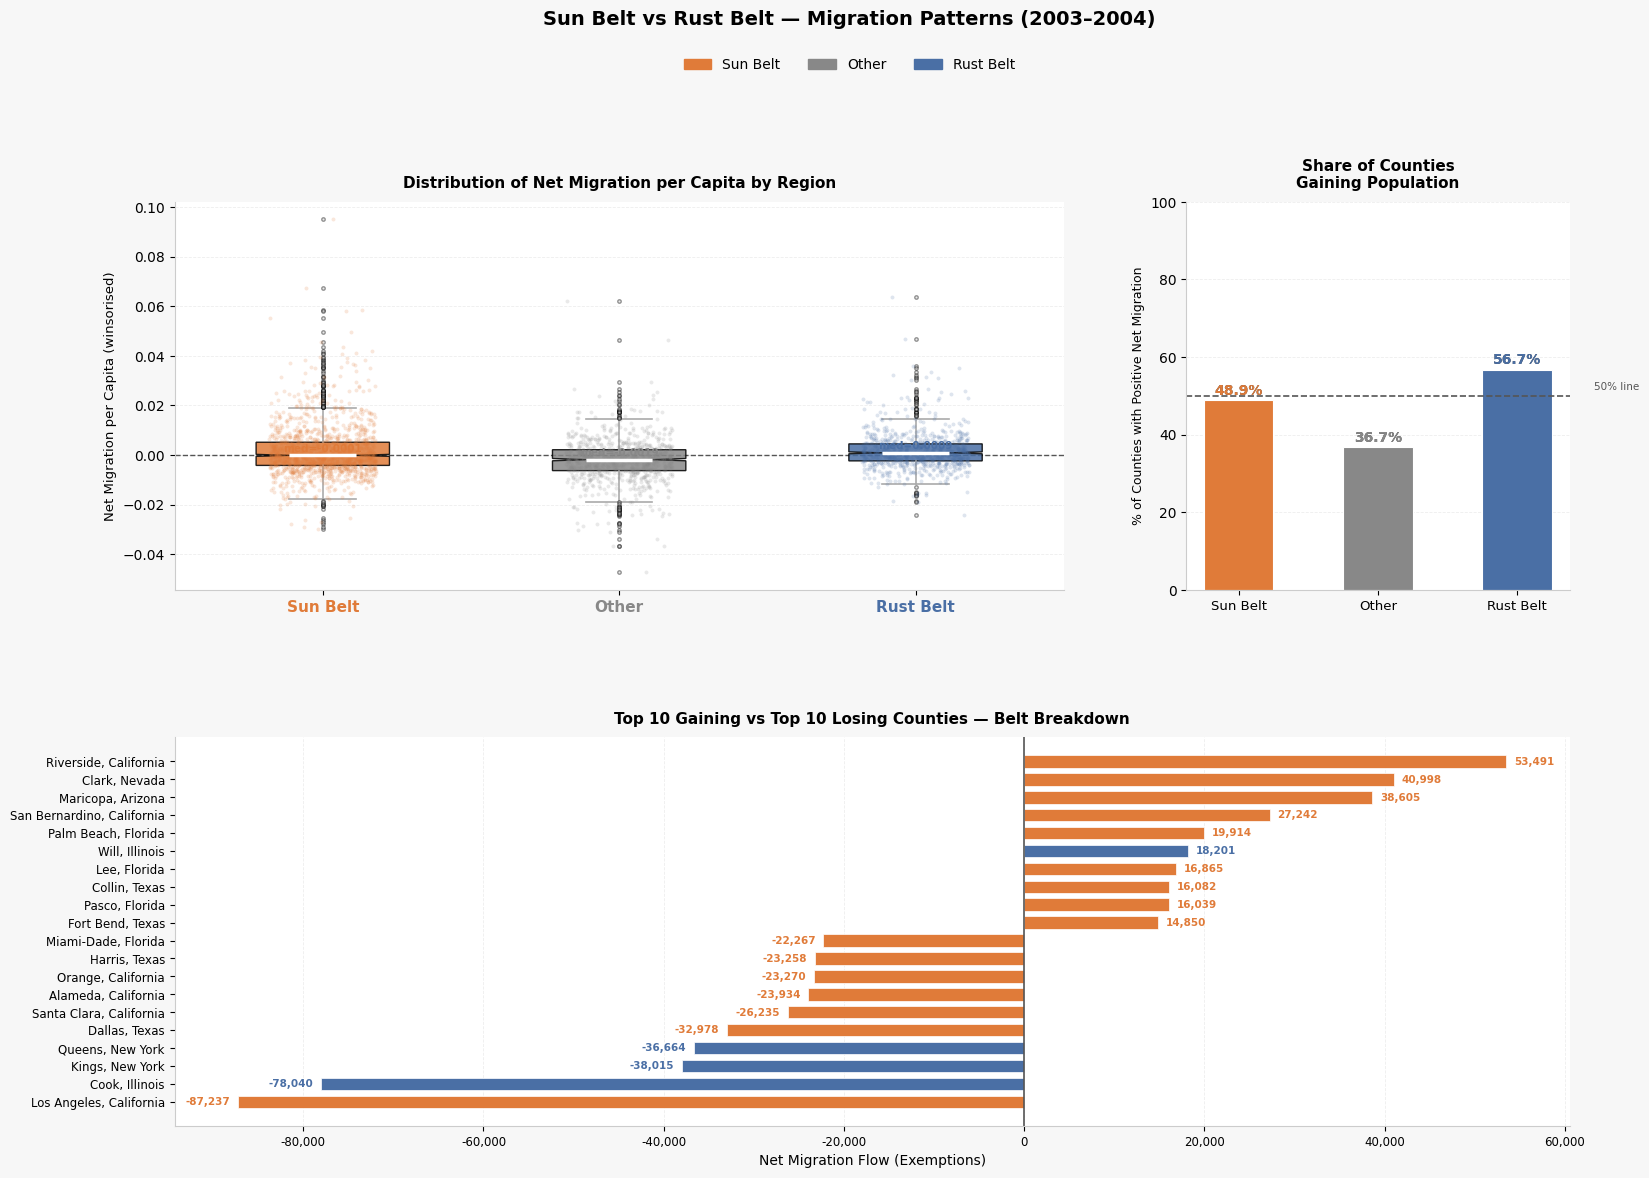

In [44]:
"""
Sun Belt vs Rust Belt — Migration Analysis (2003–2004)
=======================================================
Classifies every county into a regional belt and tests whether
Sun Belt counties are systematically gaining migrants while
Rust Belt counties are losing them.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ── Belt Classification by State ──────────────────────────────────────────────
# Sun Belt: South + Southwest + Mountain West + Pacific Coast
# Rust Belt: Northeast + Midwest industrial core
# Other: remaining states

SUN_BELT = {
    "FLORIDA", "GEORGIA", "SOUTH CAROLINA", "NORTH CAROLINA",
    "VIRGINIA", "TEXAS", "ARIZONA", "NEW MEXICO", "NEVADA",
    "CALIFORNIA", "COLORADO", "UTAH", "HAWAII",
    "TENNESSEE", "ARKANSAS", "ALABAMA", "MISSISSIPPI",
    "LOUISIANA", "OKLAHOMA"
}

RUST_BELT = {
    "NEW YORK", "NEW JERSEY", "PENNSYLVANIA", "OHIO",
    "MICHIGAN", "ILLINOIS", "INDIANA", "WISCONSIN",
    "WEST VIRGINIA", "MARYLAND", "CONNECTICUT",
    "MASSACHUSETTS", "RHODE ISLAND", "MINNESOTA", "MISSOURI"
}

def classify_belt(state):
    s = str(state).upper().strip()
    if s in SUN_BELT:
        return "Sun Belt"
    elif s in RUST_BELT:
        return "Rust Belt"
    else:
        return "Other"

df["belt"] = df["State Name"].apply(classify_belt)


COLORS = {"Sun Belt": "#E07B39", "Rust Belt": "#4A6FA5", "Other": "#888888"}

# ── Summary stats ─────────────────────────────────────────────────────────────
summary = df.groupby("belt").agg(
    Counties       = ("FIPS", "count"),
    Avg_Net_Flow   = ("Net Flow", "mean"),
    Total_Net_Flow = ("Net Flow", "sum"),
    Pct_Positive   = ("Net Flow", lambda x: (x > 0).mean() * 100),
    Avg_Per_Capita = ("net_migration_per_capita_2003", "mean"),
    Avg_Inflow     = ("Inflows", "mean"),
    Avg_Outflow    = ("Outflows", "mean"),
).round(2)

print("\n── Belt Summary ──────────────────────────────────────────────")
print(summary.to_string())

# ── Figure: 3-panel layout ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#f7f7f7")

gs = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, :2])   # top-left wide: strip/box plot
ax2 = fig.add_subplot(gs[0, 2])    # top-right: % counties with positive net migration
ax3 = fig.add_subplot(gs[1, :])    # bottom full-width: top 15 gaining & losing by belt

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor("#ffffff")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#cccccc")

# ── Panel 1: Boxplot of net migration per capita by belt ──────────────────────
belts_ordered = ["Sun Belt", "Other", "Rust Belt"]
data_by_belt  = [df[df["belt"] == b]["net_migration_per_capita_2003"].dropna().values
                 for b in belts_ordered]

bp = ax1.boxplot(data_by_belt, patch_artist=True, notch=True,
                 widths=0.45, vert=True,
                 medianprops=dict(color="white", linewidth=2.5),
                 whiskerprops=dict(color="#aaaaaa", linewidth=1.2),
                 capprops=dict(color="#aaaaaa", linewidth=1.2),
                 flierprops=dict(marker="o", markersize=2.5,
                                 markerfacecolor="#cccccc", alpha=0.4,
                                 linestyle="none"))

for patch, belt in zip(bp["boxes"], belts_ordered):
    patch.set_facecolor(COLORS[belt])
    patch.set_alpha(0.85)

# Overlay individual points (jittered)
for i, (belt, data) in enumerate(zip(belts_ordered, data_by_belt), 1):
    jitter = np.random.uniform(-0.18, 0.18, size=len(data))
    ax1.scatter(i + jitter, data, color=COLORS[belt],
                alpha=0.18, s=8, zorder=2, linewidths=0)

ax1.axhline(0, color="#555555", linewidth=1, linestyle="--", zorder=1)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(belts_ordered, fontsize=11, fontweight="bold")
for tick, belt in zip(ax1.get_xticklabels(), belts_ordered):
    tick.set_color(COLORS[belt])
ax1.set_ylabel("Net Migration per Capita (winsorised)", fontsize=9.5)
ax1.set_title("Distribution of Net Migration per Capita by Region",
              fontsize=11, fontweight="bold", pad=10)
ax1.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#eeeeee")
ax1.set_axisbelow(True)

# Annotate medians
for i, (belt, data) in enumerate(zip(belts_ordered, data_by_belt), 1):
    med = np.median(data)
    ax1.text(i, med + 0.0008, f"med={med:.4f}",
             ha="center", va="bottom", fontsize=7.5,
             fontweight="bold", color=COLORS[belt])

# ── Panel 2: % of counties with positive net migration ───────────────────────
pct_positive = [summary.loc[b, "Pct_Positive"] if b in summary.index else 0
                for b in belts_ordered]
bars = ax2.bar(belts_ordered, pct_positive,
               color=[COLORS[b] for b in belts_ordered],
               width=0.5, edgecolor="white", linewidth=0.8)
ax2.axhline(50, color="#555555", linewidth=1.2, linestyle="--")
ax2.text(2.55, 51.5, "50% line", fontsize=7.5, color="#555555")
ax2.set_ylim(0, 100)
ax2.set_ylabel("% of Counties with Positive Net Migration", fontsize=9)
ax2.set_title("Share of Counties\nGaining Population", fontsize=11,
              fontweight="bold", pad=10)
ax2.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#eeeeee")
ax2.set_axisbelow(True)
for bar, pct in zip(bars, pct_positive):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{pct:.1f}%", ha="center", fontsize=10,
             fontweight="bold", color=COLORS[belts_ordered[bars.patches.index(bar)]]
             if False else "#333333")
for bar, belt, pct in zip(bars, belts_ordered, pct_positive):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{pct:.1f}%", ha="center", fontsize=10,
             fontweight="bold", color=COLORS[belt])
ax2.tick_params(axis="x", labelsize=9.5)

# ── Panel 3: Top 10 gaining + top 10 losing counties, colored by belt ─────────
top_gaining = df.nlargest(10, "Net Flow")[["County Name","State Name","Net Flow","belt"]].copy()
top_losing  = df.nsmallest(10, "Net Flow")[["County Name","State Name","Net Flow","belt"]].copy()
combined    = pd.concat([top_gaining, top_losing]).reset_index(drop=True)
combined["Label"] = combined["County Name"].str.title() + ", " + combined["State Name"].str.title()
combined = combined.sort_values("Net Flow", ascending=True)

bar_colors = combined["belt"].map(COLORS)
bars3 = ax3.barh(combined["Label"], combined["Net Flow"],
                 color=bar_colors, edgecolor="white",
                 linewidth=0.5, height=0.7)
ax3.axvline(0, color="#555555", linewidth=1.2)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax3.xaxis.grid(True, linestyle="--", linewidth=0.6, color="#eeeeee")
ax3.set_axisbelow(True)
ax3.tick_params(axis="y", labelsize=8.5)
ax3.tick_params(axis="x", labelsize=8.5)
ax3.set_xlabel("Net Migration Flow (Exemptions)", fontsize=10)
ax3.set_title("Top 10 Gaining vs Top 10 Losing Counties — Belt Breakdown",
              fontsize=11, fontweight="bold", pad=10)

# Value labels
for bar, row in zip(bars3, combined.itertuples()):
    val = row._3  # Net Flow
    x   = bar.get_width()
    ax3.text(x + (abs(combined["Net Flow"]).max() * 0.01 * np.sign(x)),
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center",
             ha="left" if x >= 0 else "right",
             fontsize=7.5, color=COLORS[row.belt], fontweight="bold")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(color=COLORS[b], label=b) for b in belts_ordered]
fig.legend(handles=handles, loc="upper center", ncol=3,
           fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.01))

fig.suptitle("Sun Belt vs Rust Belt — Migration Patterns (2003–2004)",
             fontsize=14, fontweight="bold", y=1.04)

plt.show()

In [45]:
pair_interactions_df.to_csv("pair_interactions.csv", index=False)
inflow_df.to_csv("inflow.csv", index=False)
outflow_df.to_csv("outflow.csv", index=False)

In [46]:
total_df.to_csv("all_counties_flows.csv")
flow_df.to_csv("flows_combined.csv")